In [ ]:
import matplotlib.pyplot as plt # For plotting
import numpy as np              # Linear algebra library
import pandas as pd             # For manipulating tabular data
import time

Step 1: Create the master dataframe

In [ ]:
# Load the raw master dataset
df_master = pd.read_csv('cleaned_dataset.csv')

# Drop any rows missing labels and reset the index to establish absolute row positions
df_master = df_master.dropna(subset=['Label']).reset_index(drop=True)

df_master.describe()

,id,Q1,Q2,Q3,Q4,Q8
count,1462.000000,1462.000000,1461.000000,1461.000000,1462.000000,1461.000000
mean,460237.614911,4.321477,3.521561,3.707734,3.391929,4.796030
std,112789.365108,0.884464,1.192031,1.142037,1.297189,22.142305
min,5978.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,407927.000000,4.000000,3.000000,3.000000,2.000000,2.000000
50%,503416.000000,5.000000,4.000000,4.000000,3.000000,3.000000
75%,522169.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,727099.000000,5.000000,5.000000,5.000000,5.000000,800.000000


Step 2: Data split (same code to be used for all sub-models before individual data handling for each question)

In [ ]:
# Capture a master index array representing every single row position, and randomize rows
df_master = df_master.sample(frac=1, random_state=42).reset_index(drop=True)

master_indices = np.arange(len(df_master))
labels = df_master['Label']

# Print the first 20 rows of the shuffled dataset to verify randomization
print("=== SHUFFLE VERIFICATION REPORT ===")
print(df_master[['Label']].head(20))

print("\n=== CLASS DISTRIBUTION IN TOP 20 ROWS ===")
print(df_master['Label'].head(20).value_counts())

=== SHUFFLE VERIFICATION REPORT ===
             Label
0    New York City
1            Paris
2   Rio de Janeiro
3   Rio de Janeiro
4    New York City
5   Rio de Janeiro
6            Dubai
7            Paris
8   Rio de Janeiro
9    New York City
10  Rio de Janeiro
11           Paris
12   New York City
13  Rio de Janeiro
14           Paris
15           Paris
16           Dubai
17           Paris
18           Paris
19           Dubai

=== CLASS DISTRIBUTION IN TOP 20 ROWS ===
Label
Paris             7
Rio de Janeiro    6
New York City     4
Dubai             3
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Step A: Isolate 20% of indices for the Final Evaluation/Test Set
train_meta_idx, global_test_idx, y_train_meta, y_test = train_test_split(
    master_indices, labels, test_size=0.20, stratify=labels, random_state=42
)

# Step B: Split the remaining 80% into 70% Training and 10% Validation indices
# (0.125 * 80% = 10% of total)
global_train_idx, global_val_idx, y_train, y_val = train_test_split(
    train_meta_idx, y_train_meta, test_size=0.125, stratify=y_train_meta, random_state=42
)

# Step C: Split the 70% Training into 80% sub-model training + 20% sub-model validation
labels_train_pool = labels[global_train_idx]

train_idx, val_idx, y_sub_train, y_sub_val = train_test_split(
    global_train_idx, labels_train_pool, test_size=0.20, stratify=labels_train_pool, random_state=42
)

# Print Global Registry Summary to verify proportions
print("=== GLOBAL INDEX SPLIT REGISTRY CREATED ===")
print(f"Total Rows Available: {len(df_master)}")
print(f"Training Row Indices (70%):  {len(global_train_idx)} rows")
print(f"Validation Row Indices (10%): {len(global_val_idx)} rows")
print(f"Evaluation Row Indices (20%): {len(global_test_idx)} rows\n")
print(f"Sub-model Training Row Indices (80% of 70%):  {len(train_idx)} rows")
print(f"Sub-model Validation Row Indices (20% of 70%): {len(val_idx)} rows")

=== GLOBAL INDEX SPLIT REGISTRY CREATED ===
Total Rows Available: 1462
Training Row Indices (70%):  1022 rows
Validation Row Indices (10%): 147 rows
Evaluation Row Indices (20%): 293 rows

Sub-model Training Row Indices (80% of 70%):  817 rows
Sub-model Validation Row Indices (20% of 70%): 205 rows


Step 3: Creating one-hot encodings for Q1-Q4 data to be use for logistic regression.

In [ ]:
q1_4_features = ['Q1', 'Q2', 'Q3', 'Q4']

# Extract arrays directly from df_master, filling NaNs on-the-fly with the column median
q1 = df_master['Q1'].fillna(df_master['Q1'].median()).to_numpy()
q2 = df_master['Q2'].fillna(df_master['Q2'].median()).to_numpy()
q3 = df_master['Q3'].fillna(df_master['Q3'].median()).to_numpy()
q4 = df_master['Q4'].fillna(df_master['Q4'].median()).to_numpy()

# Generate the 14-dimensional non-linear feature matrix
poly_features = np.column_stack([
    q1, q2, q3, q4,              # Baseline terms
    q1**2, q2**2, q3**2, q4**2,  # Non-linear squared curves
    q1*q2, q1*q3, q1*q4,         # Cross-product interaction terms
    q2*q3, q2*q4, q3*q4
])

print(f"Master Dataframe Shape:   {df_master.shape}")
print(f"Polynomial Feature Shape: {poly_features.shape}")

Master Dataframe Shape:   (1462, 12)
Polynomial Feature Shape: (1462, 14)


Step 4: Q1-Q4 data exploration.

In [ ]:
# display the updated master dataframe
df_master.describe()

,id,Q1,Q2,Q3,Q4,Q8
count,1462.000000,1462.000000,1461.000000,1461.000000,1462.000000,1461.000000
mean,460237.614911,4.321477,3.521561,3.707734,3.391929,4.796030
std,112789.365108,0.884464,1.192031,1.142037,1.297189,22.142305
min,5978.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,407927.000000,4.000000,3.000000,3.000000,2.000000,2.000000
50%,503416.000000,5.000000,4.000000,4.000000,3.000000,3.000000
75%,522169.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,727099.000000,5.000000,5.000000,5.000000,5.000000,800.000000


Q1              1   2    3    4    5
Label                               
Dubai           5   5   42  162  153
New York City   2   5    6   35  317
Paris           1   5   12   72  275
Rio de Janeiro  7  24  145  136   53

Q2              1.0  2.0  3.0  4.0  5.0
Label                                  
Dubai            22   58  103  117   67
New York City     4   18   23   83  237
Paris            17   65  121   94   68
Rio de Janeiro   25  119  119   82   19

Q3              1.0  2.0  3.0  4.0  5.0
Label                                  
Dubai            14   25   51  124  153
New York City    19   58   98  112   78
Paris             8   12   48  119  178
Rio de Janeiro   17   86  140   84   37

Q4               1    2    3   4    5
Label                                
Dubai           60  106   97  67   37
New York City   30   78   94  81   82
Paris           29   99  108  82   47
Rio de Janeiro   3    8   40  82  232



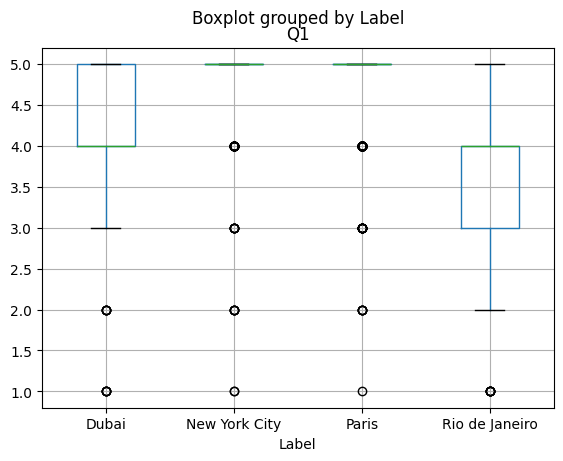

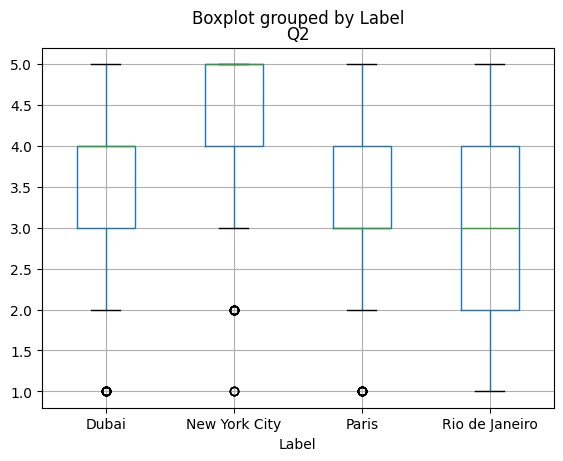

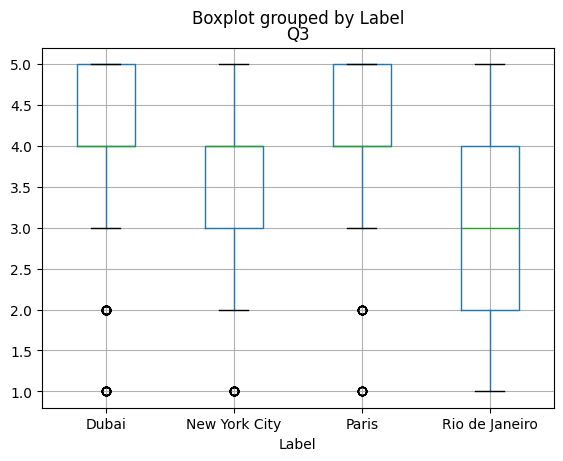

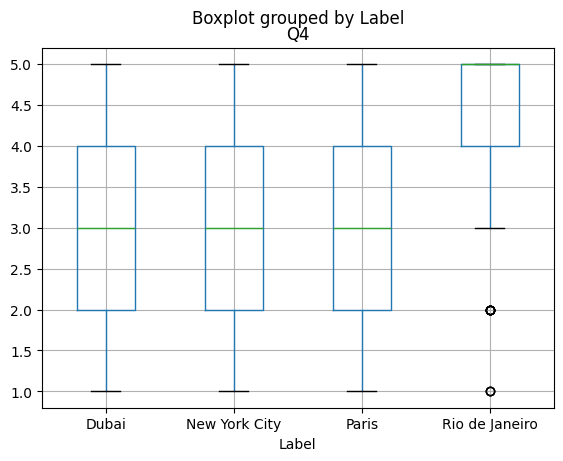

In [ ]:
# Generate boxplots and crosstabs directly from the master dataframe
for fet in ["Q1", "Q2", "Q3", "Q4"]:
    df_master.boxplot(column=fet, by='Label')

for fet in ["Q1", "Q2", "Q3", "Q4"]:
    print(pd.crosstab(df_master["Label"], df_master[fet]))
    print()

Check how many entries there are for each city.

In [ ]:
df_master['Label'].value_counts()

,count
Label,
Dubai,367
New York City,365
Paris,365
Rio de Janeiro,365


Step 5: Data splitting

In [ ]:
def convert_to_one_hot(y_raw, unique_cities=None):
    """
    Encodes a 1D array of text labels into a 2D One-Hot encoded matrix.
    Ensures that validation and test sets map to the exact same column order.
    """
    # Convert input to a standard numpy array
    y_arr = np.array(y_raw)

    # If no reference city order is passed, establish it from the unique training labels
    if unique_cities is None:
        unique_cities = np.unique(y_arr)

    # Create an empty zeros matrix of shape (Number of Samples, Number of Classes)
    num_classes = len(unique_cities)
    one_hot = np.zeros((len(y_arr), num_classes))

    # Fill in the 1s for the correct positions matching the city order index
    for idx, city in enumerate(unique_cities):
        one_hot[y_arr == city, idx] = 1.0

    return one_hot, unique_cities

In [ ]:
# Extract Train, Validation, and Test matrices using your global index masks
X_train_poly = poly_features[train_idx]
X_val_poly   = poly_features[val_idx]

# Extract synchronized raw text targets
y_train_raw = df_master['Label'].iloc[train_idx].to_numpy()
y_val_raw   = df_master['Label'].iloc[val_idx].to_numpy()

# Map raw text labels into 2D One-Hot vectors using your notebook functions
y_train_oh, city_order = convert_to_one_hot(y_train_raw)
y_val_oh, _ = convert_to_one_hot(y_val_raw, unique_cities=city_order)

print("=== Q1-4 INDEPENDENT PARTITIONS READY ===")
print(f"X_train_poly shape: {X_train_poly.shape}")
print(f"X_val_poly shape:   {X_val_poly.shape}")
print()



=== Q1-4 INDEPENDENT PARTITIONS READY ===
X_train_poly shape: (817, 14)
X_val_poly shape:   (205, 14)



Note that we do not normalize the data used since we use binary values for all features.

Step 6: Training

In [ ]:
def exp_softmax(logits):
    """
    Computes the numerically stable softmax activation.
    logits: Shape (N, K) raw predictions
    """
    shift_logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(shift_logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def compute_cross_entropy_loss(X, y_one_hot, weights):
    """
    Computes categorical cross-entropy loss over a partitioned set.
    """
    N = X.shape[0]
    logits = np.dot(X, weights)
    probs = exp_softmax(logits)
    probs = np.clip(probs, 1e-15, 1.0 - 1e-15)
    return -np.sum(y_one_hot * np.log(probs)) / N

def convert_to_one_hot(y_labels, unique_cities=None):
    """
    Maps text city strings uniformly into structured 2D matrices.
    """
    if unique_cities is None:
        unique_cities = sorted(list(np.unique(y_labels)))
    mapping = {city: i for i, city in enumerate(unique_cities)}

    one_hot = np.zeros((len(y_labels), len(unique_cities)))
    for idx, label in enumerate(y_labels):
        if label in mapping:
            one_hot[idx, mapping[label]] = 1.0
    return one_hot, unique_cities

In [ ]:
def train_logistic_regression(X_train, y_train_oh, X_val, y_val_oh, alpha=0.5, epochs=500, mode='batch', decay_rate=None):
    """
    Optimizes multi-class weights using either Full-Batch GD or SGD.
    """
    N, D = X_train.shape
    K = y_train_oh.shape[1]
    weights = np.zeros((D, K))

    train_loss_history = []
    val_loss_history = []
    lr_current = alpha

    for epoch in range(epochs):
        if mode == 'batch':
            # Vectorized batch calculation
            logits = np.dot(X_train, weights)
            probs = exp_softmax(logits)
            gradient = np.dot(X_train.T, (probs - y_train_oh)) / N
            weights -= lr_current * gradient

        elif mode == 'sgd':
            # Row-by-row stochastic calculation
            indices = np.random.permutation(N)
            for idx in indices:
                xi = X_train[idx:idx+1]
                yi = y_train_oh[idx:idx+1]
                logits = np.dot(xi, weights)
                probs = exp_softmax(logits)
                gradient = np.dot(xi.T, (probs - yi))
                weights -= lr_current * gradient

            if decay_rate:
                lr_current *= decay_rate

        # Track parameters per epoch cycle
        train_loss_history.append(compute_cross_entropy_loss(X_train, y_train_oh, weights))
        val_loss_history.append(compute_cross_entropy_loss(X_val, y_val_oh, weights))

    return weights, train_loss_history, val_loss_history

Step 6.1: Apply training function on the data

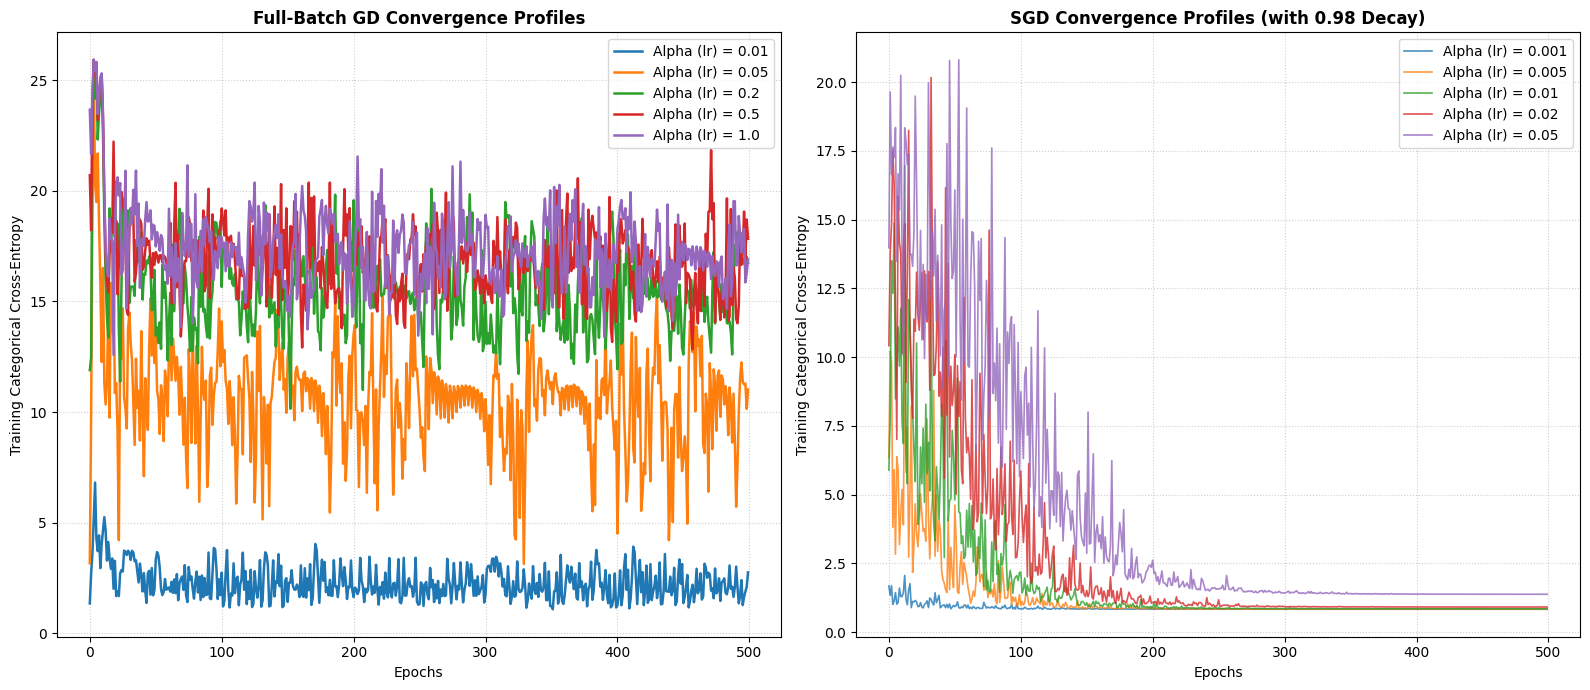

In [ ]:
import matplotlib.pyplot as plt

epochs_to_run = 500
learning_rates_gd = [0.01, 0.05, 0.2, 0.5, 1.0]
learning_rates_sgd = [0.001, 0.005, 0.01, 0.02, 0.05]

# X_train_poly and X_val_poly are already numpy arrays
X_train_mat = X_train_poly
X_val_mat   = X_val_poly

# Map raw text strings cleanly using your one-hot encoder
y_train_raw = df_master['Label'].iloc[train_idx].to_numpy()
y_val_raw   = df_master['Label'].iloc[val_idx].to_numpy()

y_train_one_hot, city_order = convert_to_one_hot(y_train_raw)
y_val_one_hot, _ = convert_to_one_hot(y_val_raw, unique_cities=city_order)

# Initialize Canvas
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
for lr in learning_rates_gd:
    _, train_loss_history, _ = train_logistic_regression(
        X_train_mat, y_train_one_hot, X_val_mat, y_val_one_hot,
        alpha=lr, epochs=epochs_to_run, mode='batch'
    )
    plt.plot(train_loss_history, label=f'Alpha (lr) = {lr}', linewidth=1.8)

plt.title('Full-Batch GD Convergence Profiles', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Training Categorical Cross-Entropy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
for lr in learning_rates_sgd:
    _, train_loss_history, _ = train_logistic_regression(
        X_train_mat, y_train_one_hot, X_val_mat, y_val_one_hot,
        alpha=lr, epochs=epochs_to_run, mode='sgd', decay_rate=0.98
    )
    plt.plot(train_loss_history, label=f'Alpha (lr) = {lr}', linewidth=1.2, alpha=0.8)

plt.title('SGD Convergence Profiles (with 0.98 Decay)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Training Categorical Cross-Entropy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Train your final definitive Q1-Q4 model weights using your optimized configuration!
final_weights, q1_4_train_loss, q1_4_val_loss = train_logistic_regression(
    X_train_poly,
    y_train_oh,
    X_val_poly,
    y_val_oh,
    alpha=0.02,
    epochs=500,
    mode='sgd'
)

Step 7: Report training/validation accuracies for the final Q1-Q4 model

In [ ]:
def compute_accuracy(X, y_raw_labels, weights, city_order):
    """
    Computes the multiclass accuracy percentage.
    """
    logits = np.dot(X, weights)
    probs = exp_softmax(logits)
    predicted_indices = np.argmax(probs, axis=1)
    predicted_labels = np.array([city_order[idx] for idx in predicted_indices])
    return np.mean(predicted_labels == y_raw_labels) * 100

# Pull training and validation text coordinates established in Step 2
# (city_order comes directly from the tracking code in your previous block)
train_acc = compute_accuracy(X_train_poly, y_train_raw, final_weights, city_order)
val_acc   = compute_accuracy(X_val_poly, y_val_raw, final_weights, city_order)

# 4. Print Formatted Performance Report
print("==================================================")
print(" Q1-4 LOGISTIC REGRESSION ACCURACY REPORT ")
print("==================================================")
print(f"Optimized Hyperparameters: Alpha = 0.5 | Epochs = 500")
print(f"Optimization Routine: Full-Batch Gradient Descent\n")
print(f"Training Accuracy (70% Pool):      {train_acc:.2f}%")
print(f"Validation Accuracy (Set B - 10%):  {val_acc:.2f}%")
print("==================================================")

 Q1-4 LOGISTIC REGRESSION ACCURACY REPORT 
Optimized Hyperparameters: Alpha = 0.5 | Epochs = 500
Optimization Routine: Full-Batch Gradient Descent

Training Accuracy (70% Pool):      63.53%
Validation Accuracy (Set B - 10%):  59.51%
